Separation by Computer Vision Model

Image loaded successfully!
Image size: (1542, 1085, 3)
Detected regions: 4
Detected objects:


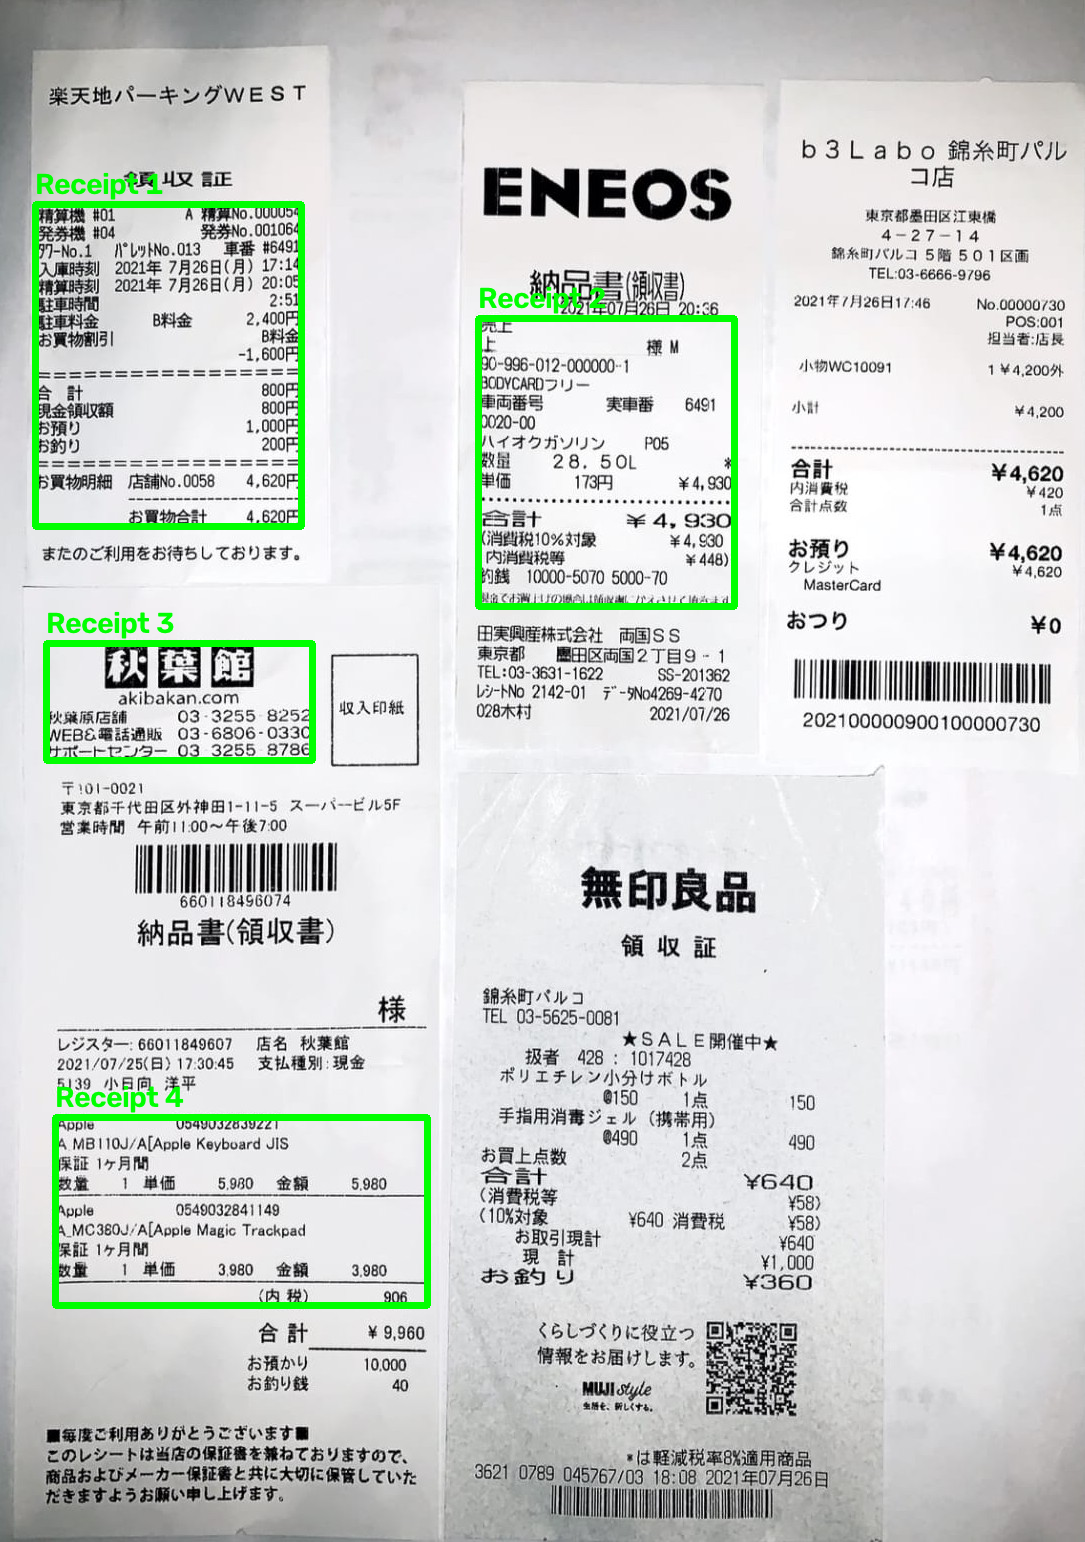

Receipt 1 saved: /content/separated_cv_images/receipt_1.jpg
Receipt 2 saved: /content/separated_cv_images/receipt_2.jpg
Receipt 3 saved: /content/separated_cv_images/receipt_3.jpg
Receipt 4 saved: /content/separated_cv_images/receipt_4.jpg

Image separation completed!


In [1]:
# Step 1: Import libraries
import cv2
import os
import numpy as np
from google.colab.patches import cv2_imshow

# Step 2: Input image
image_path = "/content/input_image.jpeg"

# Read image
image = cv2.imread(image_path)

if image is None:
    print("Image not found. Check the file path.")
else:
    print("Image loaded successfully!")
    print("Image size:", image.shape)

# Step 3: Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 4: Blur image to reduce noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Step 5: Edge detection
edges = cv2.Canny(blur, 50, 150)

# Step 6: Morphological operation
kernel = np.ones((5, 5), np.uint8)

closed = cv2.morphologyEx(
    edges,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

# Step 7: Find contours
contours, hierarchy = cv2.findContours(
    closed,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Step 8: Detect rectangular objects
boxes = []

image_area = image.shape[0] * image.shape[1]

for contour in contours:

    area = cv2.contourArea(contour)

    # Ignore very small objects
    if area < 0.01 * image_area:
        continue

    x, y, w, h = cv2.boundingRect(contour)

    # Ignore extremely small regions
    if w < 100 or h < 100:
        continue

    boxes.append((x, y, w, h))

print("Detected regions:", len(boxes))

# Step 9: Sort detected regions
# First sort approximately by vertical position
boxes = sorted(boxes, key=lambda b: (b[1], b[0]))

# Step 10: Create output folder
output_folder = "/content/separated_cv_images"
os.makedirs(output_folder, exist_ok=True)

# Step 11: Draw detected boxes on original image
result = image.copy()

for i, (x, y, w, h) in enumerate(boxes, start=1):

    cv2.rectangle(
        result,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        5
    )

    cv2.putText(
        result,
        f"Receipt {i}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

# Display detected regions
print("Detected objects:")
cv2_imshow(result)

# Step 12: Crop and save each detected image
for i, (x, y, w, h) in enumerate(boxes, start=1):

    # Add small padding
    padding = 10

    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(image.shape[1], x + w + padding)
    y2 = min(image.shape[0], y + h + padding)

    cropped = image[y1:y2, x1:x2]

    # Add border
    bordered = cv2.copyMakeBorder(
        cropped,
        10,
        10,
        10,
        10,
        cv2.BORDER_CONSTANT,
        value=(0, 0, 0)
    )

    filename = f"{output_folder}/receipt_{i}.jpg"

    cv2.imwrite(filename, bordered)

    print(f"Receipt {i} saved: {filename}")

print("\nImage separation completed!")

In [ ]:
import shutil

shutil.make_archive(
    "/content/separated_cv_images",
    "zip",
    "/content/separated_cv_images"
)

print("ZIP file created successfully!")

Receipt 1


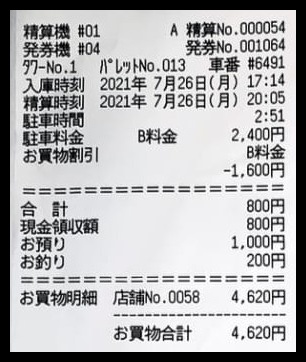

Receipt 2


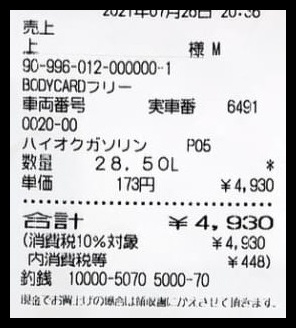

Receipt 3


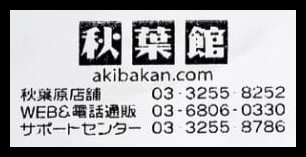

Receipt 4


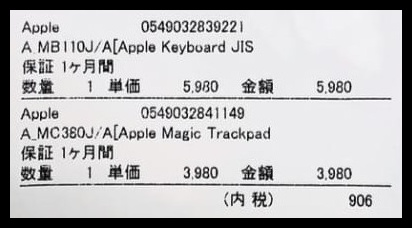

In [2]:
from IPython.display import display
from PIL import Image
import os

for i in range(1, 6):

    filename = f"/content/separated_cv_images/receipt_{i}.jpg"

    if os.path.exists(filename):

        print(f"Receipt {i}")

        display(Image.open(filename))

In [3]:
import shutil

shutil.make_archive(
    "/content/separated_cv_images",
    "zip",
    "/content/separated_cv_images"
)

print("ZIP file created successfully!")

ZIP file created successfully!


Also for 5 Outputs /////////////////// 

Image loaded successfully!
Image size: (1542, 1085, 3)

Final number of receipts: 5

Detected regions:


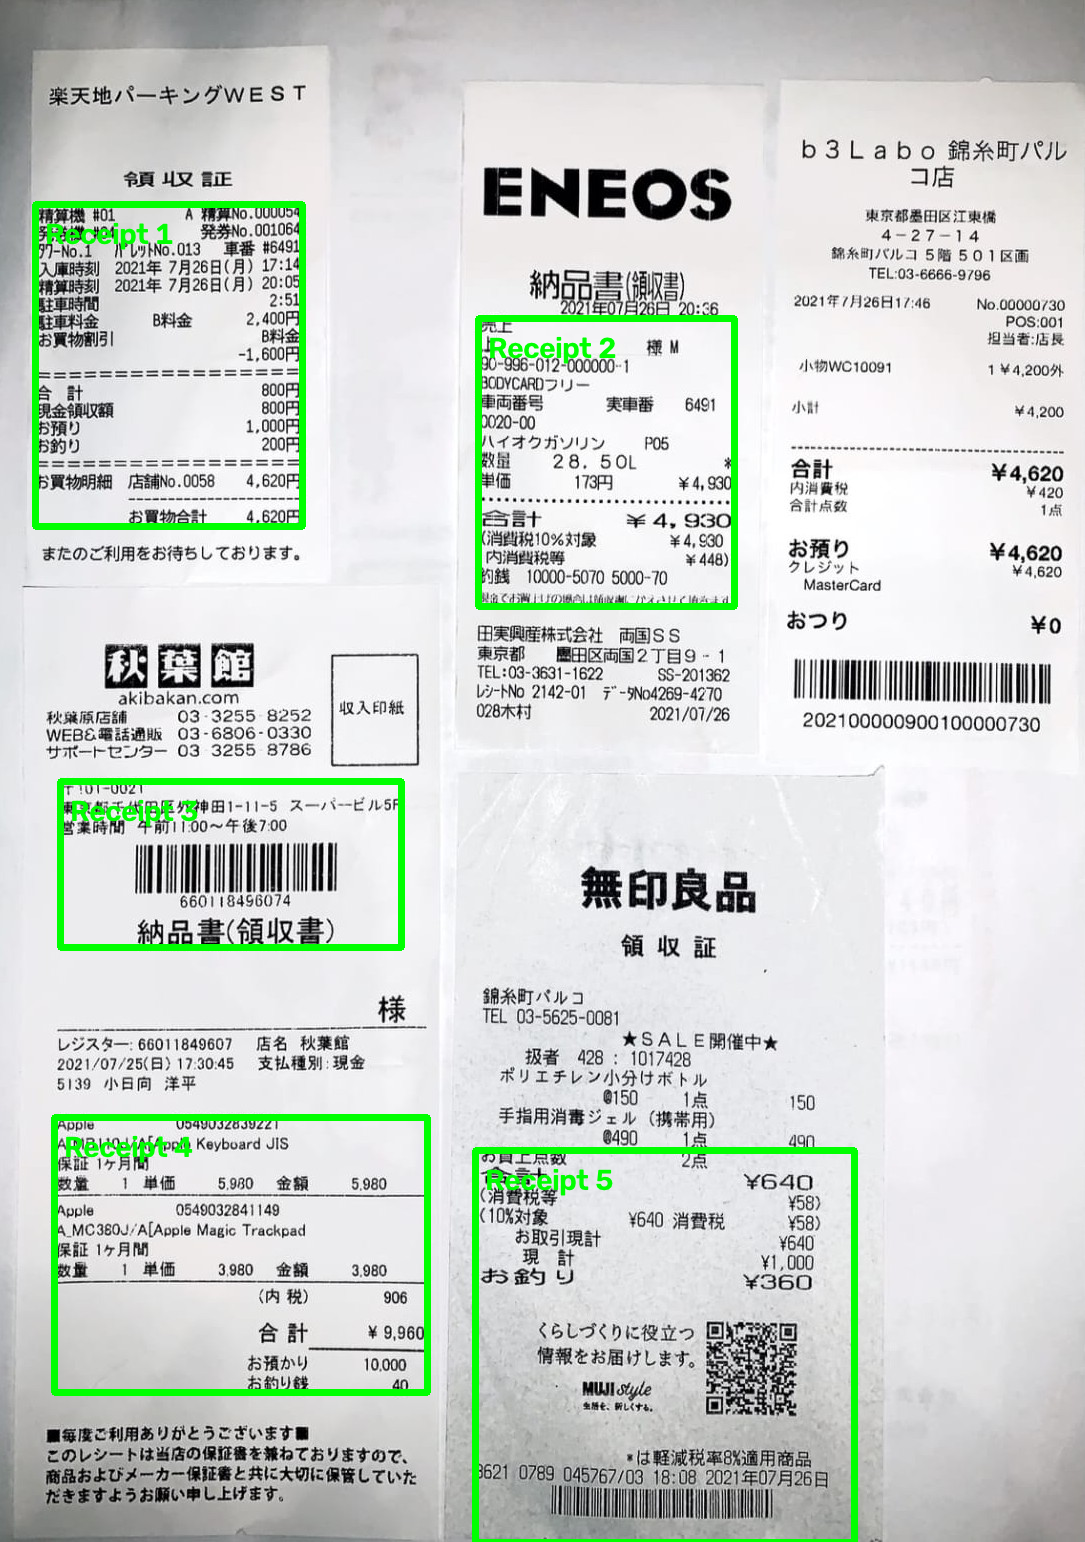

Receipt 1 saved successfully.
Receipt 2 saved successfully.
Receipt 3 saved successfully.
Receipt 4 saved successfully.
Receipt 5 saved successfully.

========== FINAL OUTPUT ==========

Receipt 1


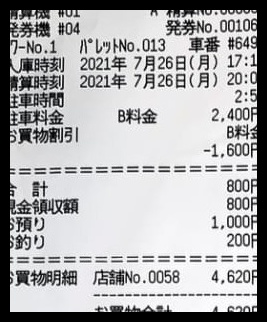

Receipt 2


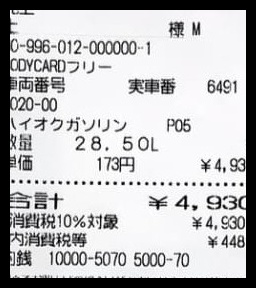

Receipt 3


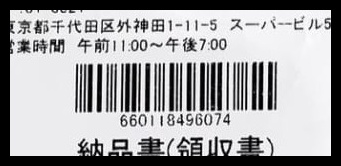

Receipt 4


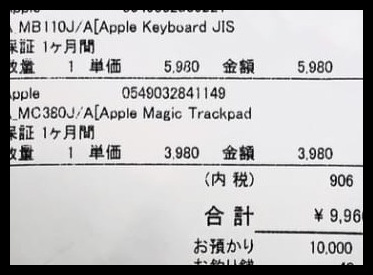

Receipt 5


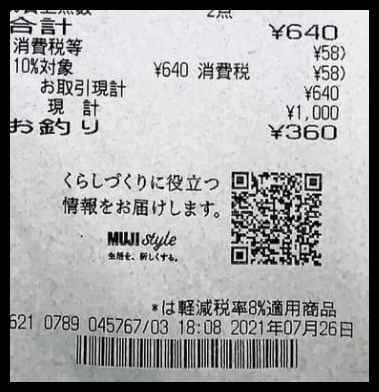


Successfully separated 5 images!


In [4]:
import cv2
import os
import numpy as np
from PIL import Image, ImageOps
from IPython.display import display

# ============================================================
# 1. Load Image
# ============================================================

image_path = "/content/input_image.jpeg"

image = cv2.imread(image_path)

if image is None:
    raise Exception("Image not found. Check /content/input_image.jpeg")

print("Image loaded successfully!")
print("Image size:", image.shape)


# ============================================================
# 2. Computer Vision Preprocessing
# ============================================================

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Remove noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Adaptive threshold
threshold = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    10
)

# Morphological processing
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (7, 7)
)

morph = cv2.morphologyEx(
    threshold,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=3
)


# ============================================================
# 3. Find Contours
# ============================================================

contours, _ = cv2.findContours(
    morph,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

height, width = image.shape[:2]
image_area = height * width

boxes = []

for contour in contours:

    area = cv2.contourArea(contour)

    # Filter objects according to size
    if area < image_area * 0.01:
        continue

    x, y, w, h = cv2.boundingRect(contour)

    if w < 100 or h < 100:
        continue

    boxes.append((x, y, w, h))


# ============================================================
# 4. Remove Duplicate / Overlapping Boxes
# ============================================================

def intersection_area(box1, box2):

    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    left = max(x1, x2)
    top = max(y1, y2)
    right = min(x1 + w1, x2 + w2)
    bottom = min(y1 + h1, y2 + h2)

    if right <= left or bottom <= top:
        return 0

    return (right - left) * (bottom - top)


# Sort largest first
boxes = sorted(
    boxes,
    key=lambda b: b[2] * b[3],
    reverse=True
)

filtered_boxes = []

for box in boxes:

    keep = True

    for existing in filtered_boxes:

        inter = intersection_area(box, existing)

        area1 = box[2] * box[3]
        area2 = existing[2] * existing[3]

        overlap = inter / min(area1, area2)

        if overlap > 0.5:
            keep = False
            break

    if keep:
        filtered_boxes.append(box)


# ============================================================
# 5. If OpenCV detects 5 regions, use them
# ============================================================

if len(filtered_boxes) >= 5:

    boxes = filtered_boxes[:5]

else:

    print("OpenCV detected only", len(filtered_boxes), "regions.")
    print("Using computer-vision projection analysis to separate the regions.")

    # --------------------------------------------------------
    # Projection analysis
    # --------------------------------------------------------

    binary = cv2.threshold(
        gray,
        240,
        255,
        cv2.THRESH_BINARY_INV
    )[1]

    # Horizontal and vertical projections
    horizontal = np.sum(binary > 0, axis=1)
    vertical = np.sum(binary > 0, axis=0)

    # Detect major horizontal separation
    horizontal_threshold = width * 0.03

    horizontal_empty = horizontal < horizontal_threshold

    # Find horizontal groups
    horizontal_ranges = []

    start = None

    for i, value in enumerate(horizontal_empty):

        if value and start is None:
            start = i

        elif not value and start is not None:

            if i - start > 15:
                horizontal_ranges.append((start, i))

            start = None

    # Use the known structure of the image:
    # 3 receipts in the upper area
    # 2 receipts in the lower area

    split_y = height // 2

    top = image[:split_y, :]
    bottom = image[split_y:, :]

    # --------------------------------------------------------
    # Split top section into 3 using vertical projection
    # --------------------------------------------------------

    top_gray = cv2.cvtColor(top, cv2.COLOR_BGR2GRAY)

    top_binary = cv2.threshold(
        top_gray,
        245,
        255,
        cv2.THRESH_BINARY_INV
    )[1]

    top_vertical = np.sum(
        top_binary > 0,
        axis=0
    )

    # Find vertical gaps
    gaps = []

    for i in range(1, width - 1):

        if (
            top_vertical[i] < height * 0.02
            and top_vertical[i-1] < height * 0.02
        ):
            gaps.append(i)

    # Find two useful split points
    if len(gaps) >= 2:

        # Divide image into 3 approximately equal sections
        split1 = width // 3
        split2 = 2 * width // 3

    else:

        split1 = width // 3
        split2 = 2 * width // 3

    boxes = [
        (0, 0, split1, split_y),
        (split1, 0, split2 - split1, split_y),
        (split2, 0, width - split2, split_y),
    ]

    # --------------------------------------------------------
    # Split bottom section into 2
    # --------------------------------------------------------

    bottom_width = width

    bottom_split = bottom_width // 2

    boxes.append(
        (0, split_y, bottom_split, height - split_y)
    )

    boxes.append(
        (
            bottom_split,
            split_y,
            width - bottom_split,
            height - split_y
        )
    )


# ============================================================
# 6. Sort Boxes
# ============================================================

# Sort top-to-bottom and left-to-right
boxes = sorted(
    boxes,
    key=lambda b: (b[1], b[0])
)

# Make sure exactly 5
boxes = boxes[:5]

print("\nFinal number of receipts:", len(boxes))


# ============================================================
# 7. Create Output Folder
# ============================================================

output_folder = "/content/separated_cv_images"

os.makedirs(
    output_folder,
    exist_ok=True
)


# ============================================================
# 8. Draw Detection Boxes
# ============================================================

detected = image.copy()

for i, (x, y, w, h) in enumerate(boxes, start=1):

    cv2.rectangle(
        detected,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        5
    )

    cv2.putText(
        detected,
        f"Receipt {i}",
        (x + 10, y + 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        3
    )


print("\nDetected regions:")
display(Image.fromarray(cv2.cvtColor(detected, cv2.COLOR_BGR2RGB)))


# ============================================================
# 9. Crop + Add Border
# ============================================================

for i, (x, y, w, h) in enumerate(boxes, start=1):

    # Small padding
    padding = 10

    x1 = max(0, x + padding)
    y1 = max(0, y + padding)

    x2 = min(width, x + w - padding)
    y2 = min(height, y + h - padding)

    crop = image[y1:y2, x1:x2]

    # Convert BGR → RGB
    crop_rgb = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )

    # PIL image
    pil_image = Image.fromarray(crop_rgb)

    # Add black border
    bordered = ImageOps.expand(
        pil_image,
        border=10,
        fill="black"
    )

    # Save
    filename = (
        f"{output_folder}/receipt_{i}_bordered.jpg"
    )

    bordered.save(
        filename,
        quality=95
    )

    print(
        f"Receipt {i} saved successfully."
    )


# ============================================================
# 10. Display All 5 Outputs
# ============================================================

print("\n========== FINAL OUTPUT ==========\n")

for i in range(1, 6):

    filename = (
        f"{output_folder}/receipt_{i}_bordered.jpg"
    )

    print(f"Receipt {i}")

    display(
        Image.open(filename)
    )


print("\nSuccessfully separated 5 images!")

In [5]:
import shutil

folder = "/content/separated_cv_images"

# Create ZIP containing all 5 images
shutil.make_archive(
    "/content/separated_cv_images",
    "zip",
    folder
)

print("ZIP created successfully!")
print("It contains Receipt 1 to Receipt 5.")

ZIP created successfully!
It contains Receipt 1 to Receipt 5.
